# PCA through Singular Value Decomposition

In [ ]:
import numpy as np

# Defined 3 points in 2D-space:
X = np.array([[2, 1, 0],
              [4, 3, 0]])

# Calculate the covariance matrix:
X_mean = X - X.mean(axis=1, keepdims=True)  # center the data
R = (X_mean @ X_mean.T) / (X.shape[1] - 1)  # 2x2 covariance matrix
print("Covariance matrix R:\n", R)

# Calculate the SVD decomposition and new basis vectors:
[U, D, V] = np.linalg.svd(R)  # call SVD decomposition
u1 = U[:, 0]  # new basis vectors
u2 = U[:, 1]
print("\nU (basis vectors):\n", U)
print("Singular values D:", D)

# Calculate the coordinates in new orthonormal basis:
Xi1 = u1 @ X_mean   # projection onto u1
Xi2 = u2 @ X_mean   # projection onto u2
print("\nCoordinates along u1:", Xi1)
print("Coordinates along u2:", Xi2)

# Calculate the approximation of the original from new basis
X_approx = u1[:, None] * Xi1[None, :] + u2[:, None] * Xi2[None, :]
print("\nApproximation (should match X_mean):\n", X_approx)

# Check that you got the original
X_reconstructed = X_approx + X.mean(axis=1, keepdims=True)
print("\nReconstructed X:\n", X_reconstructed)
print("Original X:\n", X)
print("\nMatch:", np.allclose(X_reconstructed, X))


Covariance matrix R:
 [[1.         2.        ]
 [2.         4.33333333]]

U (basis vectors):
 [[-0.4241554  -0.90558942]
 [-0.90558942  0.4241554 ]]
Singular values D: [5.27008323 0.06325011]

Coordinates along u1: [-1.9334711  -0.60372628  2.53719738]
Coordinates along u2: [-0.19866376  0.28277026 -0.0841065 ]

Approximation (should match X_mean):
 [[ 1.00000000e+00 -1.11022302e-16 -1.00000000e+00]
 [ 1.66666667e+00  6.66666667e-01 -2.33333333e+00]]

Reconstructed X:
 [[ 2.00000000e+00  1.00000000e+00  3.33066907e-16]
 [ 4.00000000e+00  3.00000000e+00 -4.44089210e-16]]
Original X:
 [[2 1 0]
 [4 3 0]]

Match: True


# PCA on Iris data

In [ ]:
# Load Iris dataset as in the last PC lab:
from sklearn.datasets import load_iris
iris=load_iris()
iris.feature_names
print(iris.feature_names)
print(iris.data[0:5,:])
print(iris.target[:])

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


<function matplotlib.pyplot.show(close=None, block=None)>

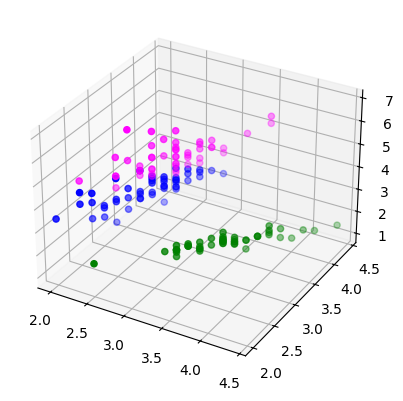

In [ ]:
# We have 4 dimensions of data, plot the first three colums in 3D
X=iris.data
y=iris.target
import matplotlib.pyplot as plt
axes1=plt.axes(projection='3d')
axes1.scatter3D(X[y==0,1],X[y==0,1],X[y==0,2],color='green')
axes1.scatter3D(X[y==1,1],X[y==1,1],X[y==1,2],color='blue')
axes1.scatter3D(X[y==2,1],X[y==2,1],X[y==2,2],color='magenta')
plt.show


Explained variance ratio: [0.72962445 0.22850762 0.03668922]
Cumulative variance explained: 99.48%

Covariance matrix in PCA space:
 [[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


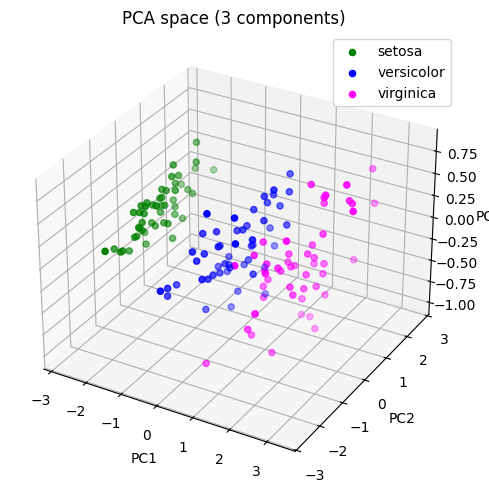

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn import decomposition
import matplotlib.pyplot as plt

Xscaler = StandardScaler()
Xpp = Xscaler.fit_transform(X)   # zero mean, unit variance per feature

# ── PCA (3 components) ───────────────────────────────────────────────────────
pca = decomposition.PCA(n_components=3)
pca.fit(Xpp)
Xpca = pca.transform(Xpp)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative variance explained: {:.2f}%".format(
      pca.explained_variance_ratio_.cumsum()[-1] * 100))
print("\nCovariance matrix in PCA space:\n", pca.get_covariance())

# ── 3D plot of the PCA-transformed space ─────────────────────────────────────
fig = plt.figure(figsize=(6, 5))          # ← fig was not defined
ax2 = fig.add_subplot(111, projection='3d')  # ← 111 not 122 (only one subplot)
ax2.scatter3D(Xpca[y==0, 0], Xpca[y==0, 1], Xpca[y==0, 2], color='green',   label='setosa')
ax2.scatter3D(Xpca[y==1, 0], Xpca[y==1, 1], Xpca[y==1, 2], color='blue',    label='versicolor')
ax2.scatter3D(Xpca[y==2, 0], Xpca[y==2, 1], Xpca[y==2, 2], color='magenta', label='virginica')
ax2.set_title("PCA space (3 components)")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.set_zlabel("PC3")
ax2.legend()

plt.tight_layout()
plt.show()


In [ ]:
# Compute pca.explained_variance_ and pca.explained_cariance_ratio_values
pca.explained_variance_

array([2.93808505, 0.9201649 , 0.14774182])

In [ ]:
pca.explained_variance_ratio_

array([0.72962445, 0.22850762, 0.03668922])

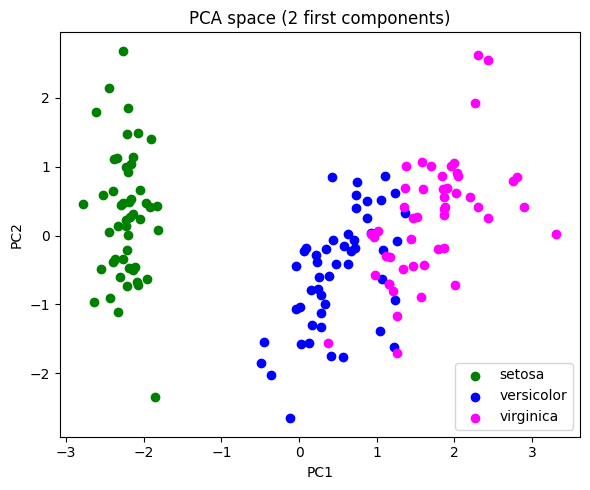

In [ ]:
# Plot the principal components in 2D, mark different targets in color
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111)

ax.scatter(Xpca[y==0, 0], Xpca[y==0, 1], color='green',   label='setosa')
ax.scatter(Xpca[y==1, 0], Xpca[y==1, 1], color='blue',    label='versicolor')
ax.scatter(Xpca[y==2, 0], Xpca[y==2, 1], color='magenta', label='virginica')

ax.set_title("PCA space (2 first components)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()

plt.tight_layout()
plt.show()

# KNN classifier

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


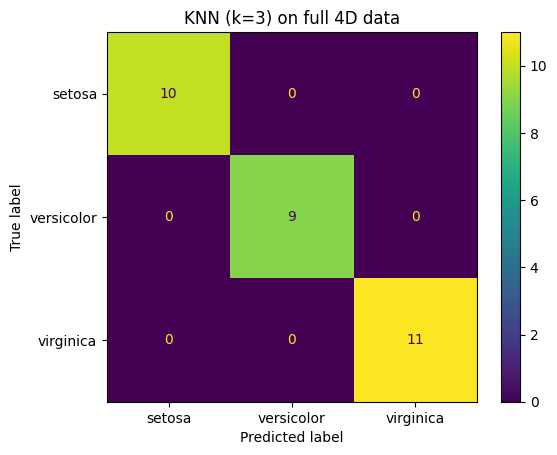

In [ ]:
# Import train_test_split as in last PC lab, split X (original) into train and test, train KNN classifier on full 4-dimensional X
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

knn1 = KNeighborsClassifier(n_neighbors=3)
knn1.fit(X_train, y_train)
Ypred = knn1.predict(X_test)

# Import and show confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

print(confusion_matrix(y_test, Ypred))
ConfusionMatrixDisplay.from_predictions(y_test, Ypred, display_labels=iris.target_names)
plt.title("KNN (k=3) on full 4D data")
plt.show()


[[10  0  0]
 [ 0  7  2]
 [ 0  0 11]]


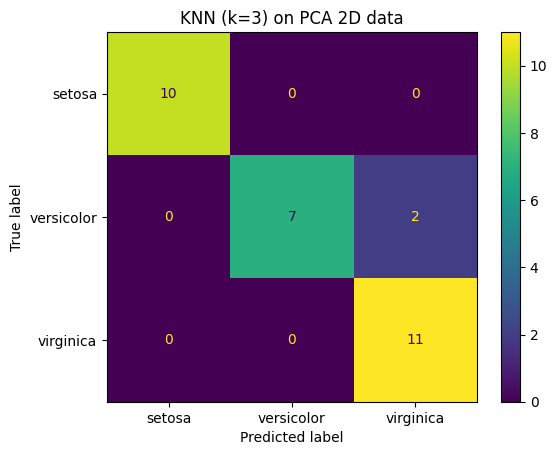

Accuracy full 4D data:  100.00%
Accuracy PCA 2D data:   93.33%


In [ ]:
# Now do the same (data set split, KNN, confusion matrix), but for PCA-transformed data (1st two principal components, i.e., first two columns).
# Compare the results with full dataset

Xpca2 = Xpca[:, 0:2]  # keep only first 2 principal components

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(Xpca2, y, test_size=0.2, random_state=42)

knn2 = KNeighborsClassifier(n_neighbors=3)
knn2.fit(X_train_pca, y_train_pca)
Ypred_pca = knn2.predict(X_test_pca)

print(confusion_matrix(y_test_pca, Ypred_pca))
ConfusionMatrixDisplay.from_predictions(y_test_pca, Ypred_pca, display_labels=iris.target_names)
plt.title("KNN (k=3) on PCA 2D data")
plt.show()

# Compare accuracy
from sklearn.metrics import accuracy_score
print("Accuracy full 4D data:  {:.2f}%".format(accuracy_score(y_test,     Ypred)     * 100))
print("Accuracy PCA 2D data:   {:.2f}%".format(accuracy_score(y_test_pca, Ypred_pca) * 100))

[[10  0  0]
 [ 0  7  2]
 [ 0  3  8]]


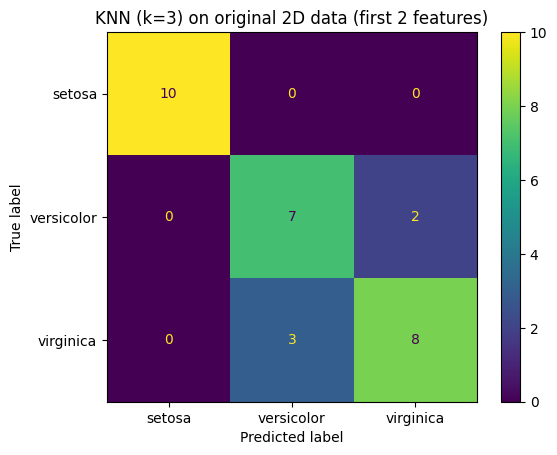

Accuracy full 4D data:       100.00%
Accuracy PCA 2D data:        93.33%
Accuracy original 2D data:   83.33%


In [ ]:
# Now do the same, but use only 2-dimensional data of original X (first two columns)
# Now do the same, but use only 2-dimensional data of original X (first two columns)

X2 = X[:, 0:2]  # keep only first 2 original features (sepal length, sepal width)

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(X2, y, test_size=0.2, random_state=42)

knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(X_train_2d, y_train_2d)
Ypred_2d = knn3.predict(X_test_2d)

print(confusion_matrix(y_test_2d, Ypred_2d))
ConfusionMatrixDisplay.from_predictions(y_test_2d, Ypred_2d, display_labels=iris.target_names)
plt.title("KNN (k=3) on original 2D data (first 2 features)")
plt.show()

# Compare all three
from sklearn.metrics import accuracy_score
print("Accuracy full 4D data:       {:.2f}%".format(accuracy_score(y_test,     Ypred)     * 100))
print("Accuracy PCA 2D data:        {:.2f}%".format(accuracy_score(y_test_pca, Ypred_pca) * 100))
print("Accuracy original 2D data:   {:.2f}%".format(accuracy_score(y_test_2d,  Ypred_2d)  * 100))

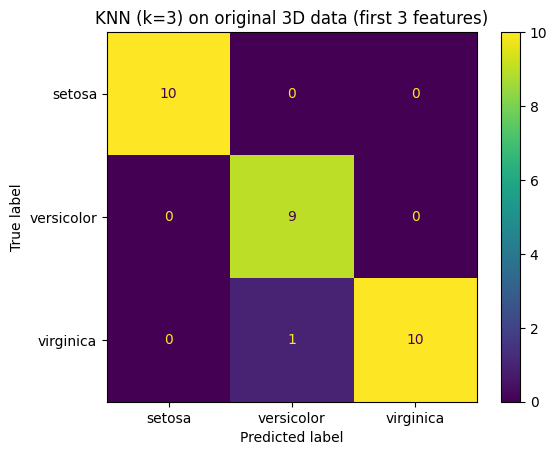

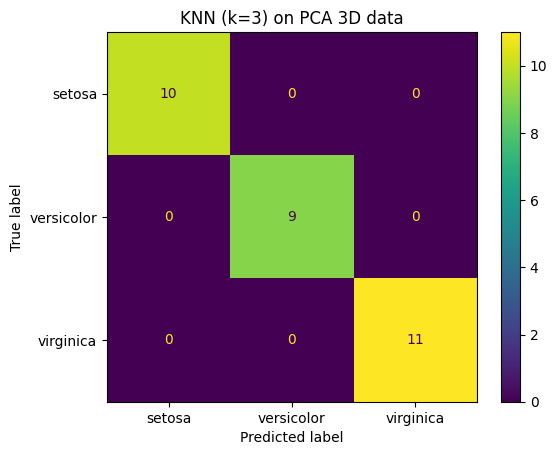

In [ ]:
# Original 3D (first 3 columns)
X_train_3d, X_test_3d, y_train_3d, y_test_3d = train_test_split(X[:, 0:3], y, test_size=0.2, random_state=42)
knn4 = KNeighborsClassifier(n_neighbors=3)
knn4.fit(X_train_3d, y_train_3d)
Ypred_3d = knn4.predict(X_test_3d)
ConfusionMatrixDisplay.from_predictions(y_test_3d, Ypred_3d, display_labels=iris.target_names)
plt.title("KNN (k=3) on original 3D data (first 3 features)")
plt.show()

# PCA 3D (first 3 principal components)
X_train_pca3, X_test_pca3, y_train_pca3, y_test_pca3 = train_test_split(Xpca[:, 0:3], y, test_size=0.2, random_state=42)
knn5 = KNeighborsClassifier(n_neighbors=3)
knn5.fit(X_train_pca3, y_train_pca3)
Ypred_pca3 = knn5.predict(X_test_pca3)
ConfusionMatrixDisplay.from_predictions(y_test_pca3, Ypred_pca3, display_labels=iris.target_names)
plt.title("KNN (k=3) on PCA 3D data")
plt.show()